# Football Match Analysis — Player Detection, Tracking & Team Classification

**Coverage:** 16 Montenegro 1.CFL matches (2025–26 season)  
**Model:** YOLOv8m fine-tuned on 971 labeled frames (person, ball)

## Pipeline
1. **Detect** players and ball using fine-tuned YOLOv8m + BoT-SORT tracking
2. **Segment** each player with YOLOv8n-seg to isolate foreground pixels
3. **Embed** masked crops via frozen ResNet18 → 512-dim CNN features
4. **Classify** teams: supervised labeling (~30 crops) → nearest-centroid in PCA space
5. **Annotate** with team-colored ellipses, ball triangles, and track IDs
6. **Export** annotated clips as MP4

In [1]:
import sys
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import importlib

sys.path.insert(0, str(Path.cwd()))

import src.config, src.video_utils, src.detection, src.team_classifier, src.tracking, src.visualization, src.segmentation
for mod in [src.config, src.video_utils, src.detection, src.team_classifier, src.tracking, src.visualization, src.segmentation]:
    importlib.reload(mod)

from src.config import Config
from src.video_utils import open_video, get_video_info, create_video_writer
from src.detection import PlayerDetector, BallInterpolator
from src.team_classifier import TeamClassifier
from src.tracking import Tracker
from src.visualization import Annotator
from src.segmentation import segment_frame, extract_player_mask

print("All modules loaded.")

In [2]:
# Use Sutjeska–Mladost for detection preview & segmentation inspection
clip_path = Config.MATCH_VIDEOS["sut-mla"]
cap = open_video(clip_path)
info = get_video_info(cap)
cap.release()
print(f"{clip_path.name}: {info['width']}x{info['height']} @ {info['fps']}fps, {info['total_frames']} frames")

SUTJESKA - MLADOST 1.CFL 21.03.2026. CIJELA UTAKMICA.mp4: 1920x1080 @ 25.0fps, 156112 frames


## 1. Detection Preview

Players detected: 10
Ball detected: 1


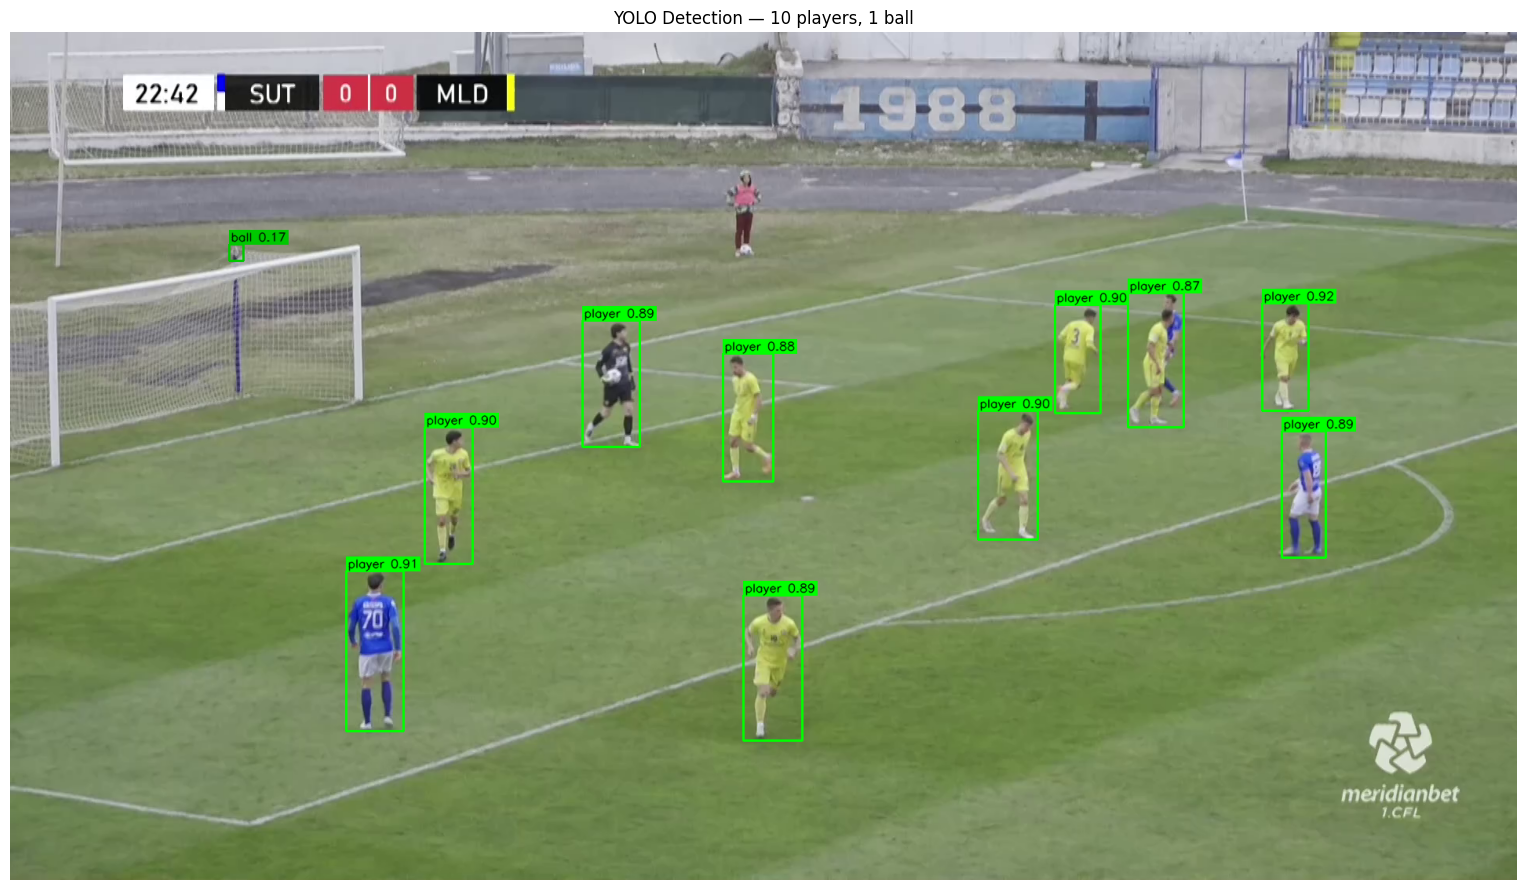

In [3]:
detector = PlayerDetector()

cap = open_video(clip_path)
# Skip ahead to get a good gameplay frame
cap.set(cv2.CAP_PROP_POS_FRAMES, int(info['fps'] * 1500))
ret, frame = cap.read()
cap.release()

detections = detector.detect(frame)
print(f"Players detected: {len(detections['players'])}")
print(f"Ball detected: {len(detections['ball'])}")

# Show debug annotation
annotator = Annotator()
debug_frame = annotator.annotate_frame_debug(frame, detections)

plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(debug_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'YOLO Detection — {len(detections["players"])} players, {len(detections["ball"])} ball')
plt.tight_layout()
plt.show()

### Segmentation Crop Inspector

For each detected player, show the raw crop, segmentation mask, and masked result side by side.

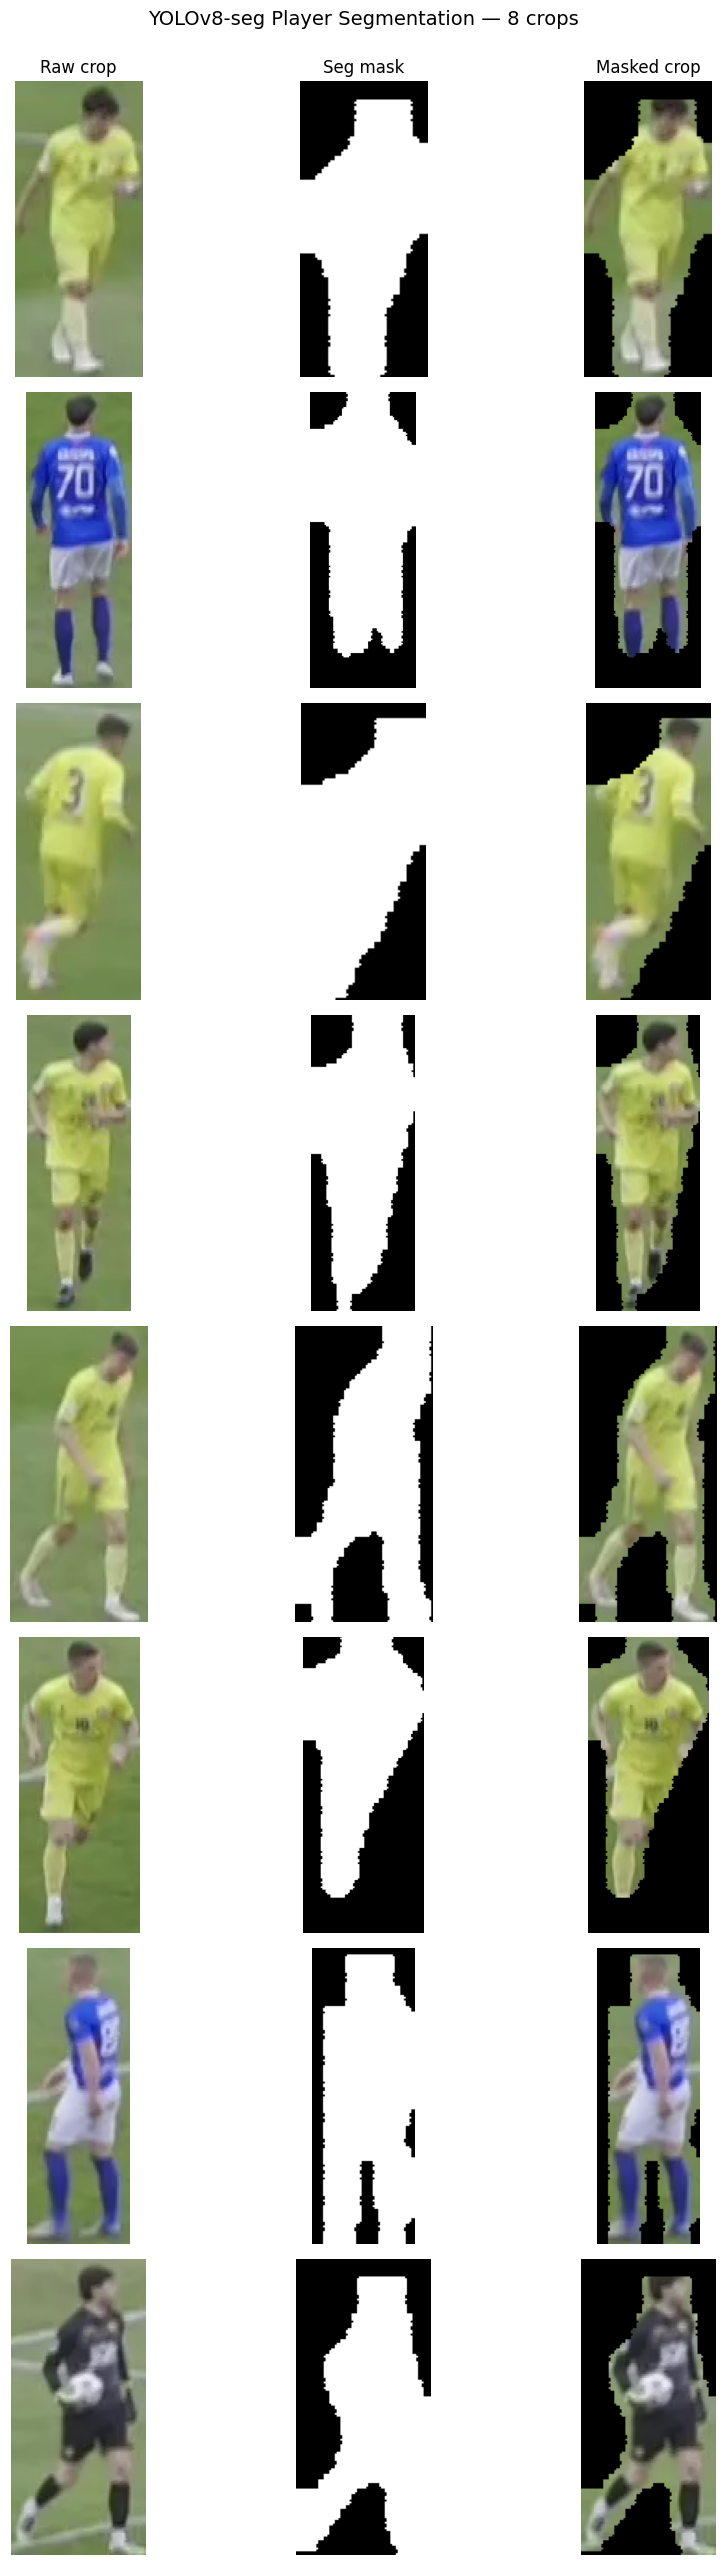

In [4]:
from ultralytics import YOLO

seg_model = YOLO(Config.YOLO_SEG_MODEL)

# Run segmentation ONCE on the full frame (model needs full-person silhouettes)
frame_mask = segment_frame(frame, seg_model)

# Use up to 8 detected players from the preview frame
players = detections['players'][:8]
n = len(players)

fig, axes = plt.subplots(n, 3, figsize=(10, 3.2 * n))
if n == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing

for row, p in enumerate(players):
    x1, y1, x2, y2 = p['bbox']
    raw_crop = frame[y1:y2, x1:x2]

    # Slice this player's mask from the full-frame mask
    masked_crop, mask = extract_player_mask(frame, p['bbox'], frame_mask)

    # Column 0 — raw crop
    axes[row, 0].imshow(cv2.cvtColor(raw_crop, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title('Raw crop' if row == 0 else '')
    axes[row, 0].axis('off')

    # Column 1 — binary mask
    axes[row, 1].imshow(mask, cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title('Seg mask' if row == 0 else '')
    axes[row, 1].axis('off')

    # Column 2 — masked crop (background zeroed)
    axes[row, 2].imshow(cv2.cvtColor(masked_crop, cv2.COLOR_BGR2RGB))
    axes[row, 2].set_title('Masked crop' if row == 0 else '')
    axes[row, 2].axis('off')

plt.suptitle(f'YOLOv8-seg Player Segmentation — {n} crops', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 3. Fit & Visualize Team Clusters

### Interactive Cluster Explorer

Hover over points to see the jersey crop that produced each color sample.

In [5]:
import plotly.graph_objects as go
import base64, io
from pathlib import Path
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
from sklearn.decomposition import PCA

THUMB_W, THUMB_H = 48, 72
INTERACTIVE_SAMPLE_EVERY = 45
EMBED_START_SEC = 10 * 60
EMBED_END_SEC   = 15 * 60
SAMPLE_EVERY_N  = 15

# All 16 matches
GAMES = [{"path": path, "slug": slug} for slug, path in Config.MATCH_VIDEOS.items()]

team_hex = {0: '#3498db', 1: '#f1c40f', 2: '#e74c3c'}
team_names_map = {0: 'Team A', 1: 'Team B', 2: 'Referee / GK'}

tab_children = []
tab_titles = []

for game in GAMES:
    video_path = Path(str(game["path"]))
    slug = game["slug"]

    if not video_path.exists():
        print(f"SKIP {slug} — video not found")
        continue

    print(f"\n{'─' * 50}")
    print(f"{slug}: {video_path.name}")

    cap = open_video(video_path)
    fps_g = cap.get(cv2.CAP_PROP_FPS)
    start_g = int(fps_g * EMBED_START_SEC)
    end_g   = int(fps_g * EMBED_END_SEC)
    clip_g  = end_g - start_g

    if clip_g <= 0:
        print(f"  SKIP — video shorter than {EMBED_START_SEC // 60} minutes")
        cap.release()
        continue

    # ── Pass 1: collect embeddings & fit GMM ──────────────────────────
    game_clf = TeamClassifier()
    game_detector = PlayerDetector()
    all_embs = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_g)
    for i in tqdm(range(clip_g), desc=f"  {slug} — embeddings", leave=False):
        ret, frame = cap.read()
        if not ret:
            break
        if i % SAMPLE_EVERY_N == 0:
            dets = game_detector.detect(frame)
            embs = game_clf.collect_embeddings(frame, dets['players'])
            all_embs.extend(embs)

    if not all_embs:
        print(f"  SKIP — no detections")
        cap.release()
        continue

    game_clf.fit(np.array(all_embs))

    # ── Pass 2: collect crops + embeddings for visualization ──────────
    viz_embeddings = []
    crop_images_b64 = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_g)
    for i in tqdm(range(clip_g), desc=f"  {slug} — viz crops", leave=False):
        ret, frame = cap.read()
        if not ret:
            break
        if i % INTERACTIVE_SAMPLE_EVERY == 0:
            dets = game_detector.detect(frame)
            if dets['players']:
                bboxes = [p['bbox'] for p in dets['players']]
                embs = game_clf.extract_embeddings_batch(frame, bboxes)
                viz_embeddings.extend(embs)
                for p in dets['players']:
                    x1, y1, x2, y2 = p['bbox']
                    crop = frame[y1:y2, x1:x2]
                    if crop.size == 0:
                        crop_images_b64.append("")
                        continue
                    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                    pil_img = Image.fromarray(crop_rgb).resize((THUMB_W, THUMB_H), Image.LANCZOS)
                    buf = io.BytesIO()
                    pil_img.save(buf, format='PNG')
                    crop_images_b64.append(base64.b64encode(buf.getvalue()).decode('utf-8'))

    cap.release()
    viz_embeddings = np.array(viz_embeddings)
    pred_team_ids = [game_clf.predict(e) for e in viz_embeddings]
    print(f"  {len(viz_embeddings)} samples with crops")

    # ── PCA 512→3 for 3D visualization ────────────────────────────────
    valid_mask = np.linalg.norm(viz_embeddings, axis=1) > 0
    viz_pca = PCA(n_components=3, random_state=42)
    viz_3d = np.zeros((len(viz_embeddings), 3), dtype=np.float32)
    if valid_mask.sum() > 3:
        viz_3d[valid_mask] = viz_pca.fit_transform(viz_embeddings[valid_mask])
        var_pct = viz_pca.explained_variance_ratio_.sum() * 100
        print(f"  Viz PCA: {var_pct:.1f}% variance in 3 components")

    # ── Build Plotly figure + hover widget for this game ──────────────
    fig = go.FigureWidget()
    for tid, tname in team_names_map.items():
        mask = [i for i, t in enumerate(pred_team_ids) if t == tid]
        if not mask:
            continue
        fig.add_trace(go.Scatter3d(
            x=viz_3d[mask, 0],
            y=viz_3d[mask, 1],
            z=viz_3d[mask, 2],
            mode='markers',
            marker=dict(size=2, color=team_hex[tid], opacity=0.6),
            name=tname,
            customdata=mask,
            hovertemplate=(
                f'<b>{tname}</b><br>'
                'PC1=%{x:.1f}<br>PC2=%{y:.1f}<br>PC3=%{z:.1f}'
                '<extra></extra>'
            ),
        ))

    fig.update_layout(
        title=f'3D Team Clusters — {slug}',
        scene=dict(
            xaxis_title='PC1',
            yaxis_title='PC2',
            zaxis_title='PC3',
        ),
        width=800, height=650,
        margin=dict(l=0, r=0, t=40, b=0),
    )

    crop_widget = widgets.Image(format='png', width=96, height=144,
                                layout=widgets.Layout(border='1px solid #ccc'))
    label_widget = widgets.HTML(value='<i>Hover over a point to see the player crop</i>')

    _blank = Image.new('RGB', (THUMB_W, THUMB_H), (220, 220, 220))
    _buf = io.BytesIO()
    _blank.save(_buf, format='PNG')
    crop_widget.value = _buf.getvalue()

    # Closure to capture per-game crop data
    def make_hover_handler(crops_b64, cw, lw):
        def handler(trace, points, state):
            if points.point_inds:
                local_idx = points.point_inds[0]
                if trace.customdata is not None:
                    global_idx = int(trace.customdata[local_idx])
                    if 0 <= global_idx < len(crops_b64) and crops_b64[global_idx]:
                        cw.value = base64.b64decode(crops_b64[global_idx])
                        lw.value = f'<b>{trace.name}</b> — sample #{global_idx}'
        return handler

    _handler = make_hover_handler(crop_images_b64, crop_widget, label_widget)
    for trace in fig.data:
        if hasattr(trace, 'customdata') and trace.customdata is not None:
            trace.on_hover(_handler)

    game_tab = widgets.HBox([
        fig,
        widgets.VBox([label_widget, crop_widget],
                     layout=widgets.Layout(padding='20px', align_items='center',
                                           justify_content='center'))
    ])
    tab_children.append(game_tab)
    tab_titles.append(slug)

# ── Display all games in tabs ─────────────────────────────────────────
tabs = widgets.Tab(children=tab_children)
for i, title in enumerate(tab_titles):
    tabs.set_title(i, title)
display(tabs)


──────────────────────────────────────────────────
bud-sut: BUDUCNOST - SUTJESKA 1.CFL 20.KOLO 21.02.2026. CIJELA UTAKMICA.mp4
TeamClassifier: ResNet18 CNN embeddings (512→32-dim PCA, k=2 GMM)


Team classification fitted on 7056 samples (512→32-dim PCA, 65.1% variance)
  Outliers removed: 353 (5.0%) — GK/ref/staff (bottom 5% membership probability)
  GMM weights  : Team A=51.1%, Team B=48.9%
  Cluster sizes: Team A=3473, Team B=3230


  2336 samples with crops
  Viz PCA: 24.1% variance in 3 components

──────────────────────────────────────────────────
ars-dec: ARSENAL - DECIC 1.CFL 21.03.2026. CIJELA UTAKMICA.mp4
TeamClassifier: ResNet18 CNN embeddings (512→32-dim PCA, k=2 GMM)


Team classification fitted on 4833 samples (512→32-dim PCA, 68.7% variance)
  Outliers removed: 242 (5.0%) — GK/ref/staff (bottom 5% membership probability)
  GMM weights  : Team A=54.9%, Team B=45.1%
  Cluster sizes: Team A=2519, Team B=2072


  1628 samples with crops
  Viz PCA: 30.6% variance in 3 components

──────────────────────────────────────────────────
bok-jed: BOKELJ - JEDINSTVO 1.CFL 22.KOLO 01.03.2026. CIJELA UTAKMICA.mp4
TeamClassifier: ResNet18 CNN embeddings (512→32-dim PCA, k=2 GMM)


...

Team classification fitted on 5669 samples (512→32-dim PCA, 65.6% variance)
  Outliers removed: 284 (5.0%) — GK/ref/staff (bottom 5% membership probability)
  GMM weights  : Team A=52.7%, Team B=47.3%
  Cluster sizes: Team A=2814, Team B=2571


  1908 samples with crops
  Viz PCA: 25.4% variance in 3 components

──────────────────────────────────────────────────
sut-mla: SUTJESKA - MLADOST 1.CFL 21.03.2026. CIJELA UTAKMICA.mp4
TeamClassifier: ResNet18 CNN embeddings (512→32-dim PCA, k=2 GMM)


Team classification fitted on 6432 samples (512→32-dim PCA, 69.6% variance)
  Outliers removed: 322 (5.0%) — GK/ref/staff (bottom 5% membership probability)
  GMM weights  : Team A=58.8%, Team B=41.2%
  Cluster sizes: Team A=3590, Team B=2520


  2145 samples with crops
  Viz PCA: 30.1% variance in 3 components


    'data': [{'customdata': [0, 4, 6, ..., 2331, 2332, 2334],
    …

## Supervised Team Labeling

Label ~30 player crops to teach the classifier which team is which.
Useful when the unsupervised GMM struggles (similar jersey colors, confusing ref kits).

**Workflow:**
1. Set `GAME_SLUG` below and run the cell → shows a labeling grid
2. Click **A** (Team A), **B** (Team B), or **X** (Other: ref/GK/staff) for each crop
3. Run the next cell → fits classifier, annotates video, exports MP4

In [8]:
import ipywidgets as widgets
from IPython.display import display
import io
from PIL import Image as PILImage

# ── Configuration ─────────────────────────────────────────────────────
GAME_SLUG = "bud-sut"        # ← change this per game
CLIP_START_SEC = 10 * 60     # 10:00
CLIP_END_SEC   = 11 * 60     # 11:00 (1 min preview — increase for longer clips)
EMBED_SAMPLE_N = 15
N_LABEL_CROPS  = 30

video_path = Path(str(Config.MATCH_VIDEOS[GAME_SLUG]))
print(f"Game: {GAME_SLUG} — {video_path.name}")

cap = cv2.VideoCapture(str(video_path))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
v_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
v_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

start_frame = int(fps * CLIP_START_SEC)
end_frame = min(int(fps * CLIP_END_SEC), total_frames - 1)
clip_frames = end_frame - start_frame
print(f"Clip: {CLIP_START_SEC//60}:00 → {CLIP_END_SEC//60}:00 ({clip_frames} frames @ {fps:.1f} fps)")

# ── Pass 1: detect + track + collect embeddings + save crops ────────
detector = PlayerDetector()
game_clf = TeamClassifier()
tracker = Tracker()

all_detections = []
track_embeddings = {}
track_crops = {}      # track_id → one representative crop (BGR)
all_embeddings = []

cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
for i in tqdm(range(clip_frames), desc=f"  {GAME_SLUG} — detect+track"):
    ret, frame = cap.read()
    if not ret:
        break

    dets = detector.detect_with_tracking(frame)
    all_detections.append(dets)

    if i % EMBED_SAMPLE_N == 0 and dets["players"]:
        embs = game_clf.collect_embeddings(frame, dets["players"])
        all_embeddings.extend(embs)
        for p, emb in zip(dets["players"], embs):
            tid = p.get("track_id", -1)
            if tid >= 0:
                track_embeddings.setdefault(tid, []).append(emb)
                if tid not in track_crops:
                    x1, y1, x2, y2 = p["bbox"]
                    crop = frame[y1:y2, x1:x2].copy()
                    if crop.size > 0:
                        track_crops[tid] = crop

# ── Select top tracks for labeling (most visible first) ───────────
sorted_tids = sorted(track_embeddings.keys(),
                     key=lambda t: len(track_embeddings[t]), reverse=True)
sample_tids = [t for t in sorted_tids if t in track_crops][:N_LABEL_CROPS]
print(f"\n{len(track_embeddings)} tracks total, labeling top {len(sample_tids)}")

# ── Labeling widget ─────────────────────────────────────────────────
COLS = 6
label_toggles = {}
summary_html = widgets.HTML()

def update_summary(*args):
    counts = {-1: 0, 0: 0, 1: 0, 2: 0}
    for t in label_toggles.values():
        counts[t.value] += 1
    summary_html.value = (
        f"<b style='color:#3498db'>Team A: {counts[0]}</b> &nbsp;|&nbsp; "
        f"<b style='color:#f39c12'>Team B: {counts[1]}</b> &nbsp;|&nbsp; "
        f"<b style='color:#888'>Other: {counts[2]}</b> &nbsp;|&nbsp; "
        f"Unlabeled: {counts[-1]}"
    )

grid_items = []
for tid in sample_tids:
    crop = track_crops[tid]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    pil = PILImage.fromarray(crop_rgb).resize((64, 96), PILImage.LANCZOS)
    buf = io.BytesIO()
    pil.save(buf, format='PNG')

    img_w = widgets.Image(value=buf.getvalue(), format='png',
                          layout=widgets.Layout(width='64px', height='96px'))

    toggle = widgets.ToggleButtons(
        options=[('?', -1), ('A', 0), ('B', 1), ('X', 2)],
        value=-1,
        style={'button_width': '24px', 'font_weight': 'bold'},
    )
    toggle.observe(update_summary, names='value')
    label_toggles[tid] = toggle

    n_embs = len(track_embeddings[tid])
    tid_label = widgets.HTML(
        f"<small>#{tid} ({n_embs}x)</small>",
        layout=widgets.Layout(text_align='center')
    )

    item = widgets.VBox(
        [img_w, toggle, tid_label],
        layout=widgets.Layout(align_items='center', margin='2px', padding='4px',
                              border='1px solid #ddd')
    )
    grid_items.append(item)

rows = [widgets.HBox(grid_items[i:i+COLS]) for i in range(0, len(grid_items), COLS)]

update_summary()
print("Label each crop: A = Team A, B = Team B, X = Other (ref/GK), ? = skip")
display(summary_html)
display(widgets.VBox(rows))

Game: bud-sut — BUDUCNOST - SUTJESKA 1.CFL 20.KOLO 21.02.2026. CIJELA UTAKMICA.mp4
Clip: 10:00 → 11:00 (1500 frames @ 25.0 fps)
TeamClassifier: ResNet18 CNN embeddings (512→32-dim PCA)


  bud-sut — detect+track: 100%|██████████| 1500/1500 [01:02<00:00, 23.85it/s]



119 tracks total, labeling top 30
Label each crop: A = Team A, B = Team B, X = Other (ref/GK), ? = skip


HTML(value="<b style='color:#3498db'>Team A: 0</b> &nbsp;|&nbsp; <b style='color:#f39c12'>Team B: 0</b> &nbsp;…

In [9]:
# ── Collect labels from widget ───────────────────────────────────────
labeled_embs = []
labeled_labels = []

for tid, toggle in label_toggles.items():
    if toggle.value == -1:  # unlabeled, skip
        continue
    for emb in track_embeddings[tid]:
        labeled_embs.append(emb)
        labeled_labels.append(toggle.value)

n_labeled = sum(1 for t in label_toggles.values() if t.value != -1)
print(f"Labeled: {n_labeled} tracks → {len(labeled_embs)} embeddings")

if len(labeled_embs) < 4:
    print("Need at least 4 labeled crops. Go back and label more.")
else:
    # ── Fit supervised classifier ─────────────────────────────────────
    game_clf.fit_supervised(np.array(labeled_embs), labeled_labels)

    # ── Classify ALL tracks (including unlabeled ones) ─────────────
    track_teams = game_clf.classify_tracks(track_embeddings)
    tracker.set_track_teams(track_teams)

    class_names = {0: 'Team A', 1: 'Team B', 2: 'Other'}
    counts = {}
    for t in track_teams.values():
        counts[t] = counts.get(t, 0) + 1
    summary = ', '.join(f"{class_names.get(k, '?')}={v}" for k, v in sorted(counts.items()))
    print(f"Track-level: {len(track_teams)} tracks classified ({summary})")

    # Apply to all detections
    for dets in all_detections:
        for p in dets["players"]:
            tid = p.get("track_id", -1)
            p["team_id"] = tracker.get_team(tid)

    # ── Ball interpolation ───────────────────────────────────────────
    interpolator = BallInterpolator(max_gap=15)
    detected_count = sum(1 for d in all_detections if d["ball"])
    interpolator.interpolate(all_detections)
    total_with_ball = sum(1 for d in all_detections if d["ball"])
    print(f"Ball: {detected_count} detected + {total_with_ball - detected_count} interpolated")

    # ── Pass 2: annotate ─────────────────────────────────────────────
    annotator = Annotator()
    output_path = Config.OUTPUT_DIR / f"{GAME_SLUG}_supervised.mp4"
    Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    writer = create_video_writer(output_path, fps, v_width, v_height)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    for i in tqdm(range(len(all_detections)), desc=f"  {GAME_SLUG} — annotating"):
        ret, frame = cap.read()
        if not ret:
            break
        annotated = annotator.annotate_frame(frame, all_detections[i])
        writer.write(annotated)

    writer.release()
    cap.release()

    size_mb = output_path.stat().st_size / 1e6
    print(f"Saved: {output_path.name} ({size_mb:.1f} MB)")

Labeled: 29 tracks → 771 embeddings
Supervised fit: 771 embeddings, 32-dim PCA (70.1% variance)
  Classes: Team A=439, Team B=241, Other=91
Track-level: 119 tracks classified (Team A=54, Team B=56, Other=9)
Ball: 590 detected + 171 interpolated


  bud-sut — annotating: 100%|██████████| 1500/1500 [00:18<00:00, 83.14it/s]

Saved: bud-sut_supervised.mp4 (82.4 MB)
